# Milestone 2: Data Processing & Transformation
**Project:** Public Health Data Visualization System  
**Dataset:** Global Health Statistics (1,000,000 records × 22 columns)  

**Objective:** Develop a robust, reproducible data processing pipeline that cleans, transforms, and engineers features from the raw dataset.

---
**Assigned to:** *(Ritah, Sharon, Joyce, Christine, Jubilee)*  
**Branch:** `feature/milestone2-pipeline`

> **Before starting:** Run `load_dataset.ipynb` to confirm the dataset is available locally.

---
## 1. Setup & Data Loading

**What to do here:**
- Import all required libraries (`pandas`, `numpy`, `os`, `pathlib`, etc.)
- Load the raw dataset from `data/raw/` using a reproducible file path
- Print the shape and a preview of the data to confirm it loaded correctly

**Deliverable check:** The pipeline must start from a reproducible data source — no hardcoded absolute paths.

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path

# Resolving project root and defining file paths
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
RAW_DATA = PROJECT_ROOT / 'data' / 'raw' / 'Global Health Statistics.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Dataset path : {RAW_DATA}')
print(f'Dataset exists: {RAW_DATA.exists()}')

df = pd.read_csv(RAW_DATA)
print(f'\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Project root : /home/mendarrr/Projects/Data Science/Python/Data-Visualization-Project
Dataset path : /home/mendarrr/Projects/Data Science/Python/Data-Visualization-Project/data/raw/Global Health Statistics.csv
Dataset exists: True

Shape: 1,000,000 rows x 22 columns


,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007,...,7.58,Medication,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318,...,5.11,Surgery,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878,...,3.49,Vaccination,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224,...,8.44,Surgery,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908,...,5.90,Medication,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


---
## 2. Data Quality Audit

**What to do here:**
- Scan for **missing values** — count and percentage per column
- Detect **duplicate rows**
- Identify **statistical anomalies/outliers** in numerical columns (e.g., using IQR or z-score)
- Check for **invalid values** (e.g., percentages outside 0–100, negative values where impossible)
- Check **data types** — are columns stored as the correct type?

**Deliverable check:** This section documents all issues *before* they are fixed. Think of it as a diagnostic report.

In [33]:
# Check for missing values (count + percentage per column)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Report:")
print(missing_df)
print(f"\nTotal rows with at least one missing value: {df.isnull().any(axis=1).sum()}")

Missing Values Report:
                                Column  Missing_Count  Missing_Percentage
0                              Country              0                 0.0
1                                 Year              0                 0.0
2                         Disease Name              0                 0.0
3                     Disease Category              0                 0.0
4                  Prevalence Rate (%)              0                 0.0
5                   Incidence Rate (%)              0                 0.0
6                   Mortality Rate (%)              0                 0.0
7                            Age Group              0                 0.0
8                               Gender              0                 0.0
9                  Population Affected              0                 0.0
10               Healthcare Access (%)              0                 0.0
11                    Doctors per 1000              0                 0.0
12             

In [34]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
print(f"Unique rows: {len(df) - duplicates}")
print(f"Duplicate ratio: {(duplicates / len(df) * 100):.2f}%")

# Show duplicate rows if any exist
if duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))
else:
    print("\nNo duplicate rows found.")

Total duplicate rows: 0
Unique rows: 1000000
Duplicate ratio: 0.00%

No duplicate rows found.


In [35]:
# Check data types and flag any mismatches
print("Current Data Types:")
print(df.dtypes)
print("\n" + "="*60)

# Identify potential type mismatches
dtype_issues = []

for col in df.columns:
    # Check if numeric columns are stored as object
    if 'rate' in col.lower() or 'percentage' in col.lower() or 'population' in col.lower():
        if df[col].dtype == 'object':
            dtype_issues.append(f"'{col}' — should be numeric but is {df[col].dtype}")
    
    # Check if year columns are numeric
    if 'year' in col.lower():
        if df[col].dtype != 'int64' and df[col].dtype != 'float64':
            dtype_issues.append(f"'{col}' — should be numeric but is {df[col].dtype}")
    
    # Check for date-like columns stored as strings
    if 'date' in col.lower():
        if df[col].dtype == 'object':
            dtype_issues.append(f"'{col}' — should be datetime but is {df[col].dtype}")

print("\nData Type Issues Found:")
if dtype_issues:
    for issue in dtype_issues:
        print(f"  ⚠ {issue}")
else:
    print("  ✓ No obvious type mismatches detected.")

# Show memory usage by dtype
print("\n" + "="*60)
print("Memory Usage by Data Type:")
print(df.memory_usage(deep=True) / 1024**2)  # in MB

Current Data Types:
Country                                   str
Year                                    int64
Disease Name                              str
Disease Category                          str
Prevalence Rate (%)                   float64
Incidence Rate (%)                    float64
Mortality Rate (%)                    float64
Age Group                                 str
Gender                                    str
Population Affected                     int64
Healthcare Access (%)                 float64
Doctors per 1000                      float64
Hospital Beds per 1000                float64
Treatment Type                            str
Average Treatment Cost (USD)            int64
Availability of Vaccines/Treatment        str
Recovery Rate (%)                     float64
DALYs                                   int64
Improvement in 5 Years (%)            float64
Per Capita Income (USD)                 int64
Education Index                       float64
Urbanization R

In [36]:
# Detect outliers/anomalies in numerical columns (IQR or z-score method)
from scipy import stats

# Get numerical columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("OUTLIER DETECTION — IQR Method")
print("="*60)

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    if outlier_count > 0:
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_pct,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("✓ No outliers detected using IQR method.")

# Z-score method (values with |z-score| > 3 are extreme outliers)
print("\n" + "="*60)
print("OUTLIER DETECTION — Z-Score Method (|z| > 3)")
print("="*60)

z_outliers = []
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    extreme_outliers = (z_scores > 3).sum()
    if extreme_outliers > 0:
        z_outliers.append({
            'Column': col,
            'Extreme_Outliers_(z>3)': extreme_outliers,
            'Percentage': (extreme_outliers / len(df)) * 100
        })

if z_outliers:
    z_df = pd.DataFrame(z_outliers).sort_values('Extreme_Outliers_(z>3)', ascending=False)
    print(z_df.to_string(index=False))
else:
    print("✓ No extreme outliers detected using z-score method.")

OUTLIER DETECTION — IQR Method
✓ No outliers detected using IQR method.

OUTLIER DETECTION — Z-Score Method (|z| > 3)
✓ No extreme outliers detected using z-score method.


In [37]:
# Check for invalid values (e.g., rates outside 0-100, negative populations)
print("INVALID VALUES CHECK")
print("="*60)

invalid_issues = []

for col in df.columns:
    # Check for negative values in columns that should be non-negative (only numeric columns)
    if ('population' in col.lower() or 'count' in col.lower() or 'cases' in col.lower()) and df[col].dtype in ['float64', 'int64']:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            invalid_issues.append({
                'Column': col,
                'Issue': 'Negative values (should be ≥0)',
                'Count': negative_count,
                'Percentage': (negative_count / len(df)) * 100
            })
    
    # Check for percentages/rates outside 0-100 range
    if ('rate' in col.lower() or 'percentage' in col.lower() or '(%)' in col) and df[col].dtype in ['float64', 'int64']:
        below_0 = (df[col] < 0).sum()
        above_100 = (df[col] > 100).sum()
        
        if below_0 > 0:
            invalid_issues.append({
                'Column': col,
                'Issue': 'Below 0 (should be 0-100)',
                'Count': below_0,
                'Percentage': (below_0 / len(df)) * 100
            })
        if above_100 > 0:
            invalid_issues.append({
                'Column': col,
                'Issue': 'Above 100 (should be 0-100)',
                'Count': above_100,
                'Percentage': (above_100 / len(df)) * 100
            })

if invalid_issues:
    invalid_df = pd.DataFrame(invalid_issues).sort_values('Count', ascending=False)
    print(invalid_df.to_string(index=False))
else:
    print("✓ No invalid values detected.")

# Show sample statistics for key numeric columns
print("\n" + "="*60)
print("Numeric Column Statistics (Quick Check):")
print("="*60)
numeric_stats = df.select_dtypes(include=[np.number]).describe().loc[['min', 'max']].T
print(numeric_stats)

INVALID VALUES CHECK
✓ No invalid values detected.

Numeric Column Statistics (Quick Check):
                                 min        max
Year                          2000.0     2024.0
Prevalence Rate (%)              0.1       20.0
Incidence Rate (%)               0.1       15.0
Mortality Rate (%)               0.1       10.0
Population Affected           1000.0  1000000.0
Healthcare Access (%)           50.0      100.0
Doctors per 1000                 0.5        5.0
Hospital Beds per 1000           0.5       10.0
Average Treatment Cost (USD)   100.0    50000.0
Recovery Rate (%)               50.0       99.0
DALYs                            1.0     5000.0
Improvement in 5 Years (%)       0.0       10.0
Per Capita Income (USD)        500.0   100000.0
Education Index                  0.4        0.9
Urbanization Rate (%)           20.0       90.0


**Audit Summary** *(fill in after running the cells above)*

| Issue | Column(s) Affected | Count | Action Planned |
|---|---|---|---|
| Missing values | | | |
| Duplicate rows | — | | |
| Outliers | | | |
| Invalid values | | | |
| Type mismatches | | | |

---
## 3. Data Cleaning & Standardization

**What to do here:**
- Handle **missing values** (impute, drop, or flag — justify your choice)
- Remove or correct **duplicate rows**
- Handle **outliers** (cap, remove, or transform — justify your choice)
- Fix **data type mismatches** (e.g., convert columns to correct types)
- Standardize **string/categorical values** (e.g., consistent casing, strip whitespace)
- Correct any **invalid values** found in the audit

**Deliverable check:** Each cleaning step should be a reusable function where possible, making the pipeline reproducible.

In [38]:
# Handle missing values
# Strategy:
#   - Numeric columns: impute with median (robust to outliers)
#   - Categorical columns: impute with mode (most frequent value)
#   - Create indicator columns for rows that had missing values (for feature engineering)

df_cleaned = df.copy()

# Track which rows had missing values
df_cleaned['Had_Missing_Values'] = df.isnull().any(axis=1).astype(int)

print("Missing Values Handling:")
print("="*60)

# Identify columns with missing values
cols_with_missing = df_cleaned.isnull().sum()
cols_with_missing = cols_with_missing[cols_with_missing > 0]

if len(cols_with_missing) > 0:
    print(f"Columns with missing values: {list(cols_with_missing.index)}")
    
    for col in cols_with_missing.index:
        if df_cleaned[col].dtype in ['float64', 'int64']:
            # Numeric: impute with median
            median_val = df_cleaned[col].median()
            df_cleaned[col].fillna(median_val, inplace=True)
            print(f"  • {col}: Imputed {cols_with_missing[col]} values with median ({median_val:.2f})")
        else:
            # Categorical: impute with mode
            mode_val = df_cleaned[col].mode()[0]
            df_cleaned[col].fillna(mode_val, inplace=True)
            print(f"  • {col}: Imputed {cols_with_missing[col]} values with mode ('{mode_val}')")
else:
    print("✓ No missing values found — no imputation needed.")

print("\n" + "="*60)
print(f"Rows with missing values flag: {df_cleaned['Had_Missing_Values'].sum()}")
print(f"Remaining missing values in dataset: {df_cleaned.isnull().sum().sum()}")


Missing Values Handling:
✓ No missing values found — no imputation needed.

Rows with missing values flag: 0
Remaining missing values in dataset: 0


In [39]:
# Remove duplicate rows
print("Duplicate Rows Removal:")
print("="*60)

rows_before = len(df_cleaned)

# Remove exact duplicates (all columns match)
df_cleaned = df_cleaned.drop_duplicates()

rows_after = len(df_cleaned)
rows_removed = rows_before - rows_after

print(f"Rows before deduplication: {rows_before:,}")
print(f"Rows after deduplication: {rows_after:,}")
print(f"Duplicate rows removed: {rows_removed:,}")
print(f"Duplicate ratio: {(rows_removed / rows_before * 100):.2f}%")

if rows_removed > 0:
    print(f"\n✓ Successfully removed {rows_removed:,} duplicate rows.")
else:
    print("\n✓ No duplicate rows found.")

Duplicate Rows Removal:
Rows before deduplication: 1,000,000
Rows after deduplication: 1,000,000
Duplicate rows removed: 0
Duplicate ratio: 0.00%

✓ No duplicate rows found.


In [40]:
# Handle outliers
# Approach: Cap at IQR bounds (preserves data volume while reducing extreme values)
# Justification: Capping is preferred over removal to maintain sample size; more robust than winsorization for extreme outliers

print("Outlier Handling:")
print("="*60)

# Track rows with outliers
df_cleaned['Had_Outliers'] = False

numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
outlier_caps_applied = []

for col in numeric_cols:
    # Skip the indicator columns we added
    if col in ['Had_Missing_Values', 'Had_Outliers']:
        continue
    
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers before capping
    outliers_below = (df_cleaned[col] < lower_bound).sum()
    outliers_above = (df_cleaned[col] > upper_bound).sum()
    
    if outliers_below > 0 or outliers_above > 0:
        # Mark rows with outliers
        df_cleaned.loc[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound), 'Had_Outliers'] = True
        
        # Cap values at bounds
        df_cleaned[col] = df_cleaned[col].clip(lower_bound, upper_bound)
        
        outlier_caps_applied.append({
            'Column': col,
            'Below_Lower_Bound': outliers_below,
            'Above_Upper_Bound': outliers_above,
            'Total_Capped': outliers_below + outliers_above,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

if outlier_caps_applied:
    outlier_caps_df = pd.DataFrame(outlier_caps_applied)
    print(outlier_caps_df.to_string(index=False))
    print(f"\n✓ Successfully capped {outlier_caps_df['Total_Capped'].sum():,} outlier values across {len(outlier_caps_df)} columns.")
else:
    print("✓ No outliers detected — no capping needed.")

print("\n" + "="*60)
print(f"Rows with outliers capped: {df_cleaned['Had_Outliers'].sum():,}")

Outlier Handling:
✓ No outliers detected — no capping needed.

Rows with outliers capped: 0


In [41]:
# Fix data types (e.g., Year to int, categorical columns to category dtype)
print("Data Type Conversion:")
print("="*60)

dtypes_before = df_cleaned.dtypes.copy()

# Convert Year to int
if 'Year' in df_cleaned.columns:
    df_cleaned['Year'] = df_cleaned['Year'].astype('int64')
    print("✓ Year converted to int64")

# Identify and convert categorical columns (object dtype columns with high cardinality are typically categorical)
categorical_cols = df_cleaned.select_dtypes(include='object').columns.tolist()

# Remove indicator columns from categorical conversion
categorical_cols = [col for col in categorical_cols if col not in ['Had_Missing_Values', 'Had_Outliers']]

conversions = []
for col in categorical_cols:
    unique_count = df_cleaned[col].nunique()
    total_rows = len(df_cleaned)
    uniqueness_pct = (unique_count / total_rows) * 100
    
    # Convert to category if unique values < 20% of total rows (typical threshold for categorical data)
    if uniqueness_pct < 20:
        df_cleaned[col] = df_cleaned[col].astype('category')
        conversions.append({
            'Column': col,
            'Original_Type': 'object',
            'New_Type': 'category',
            'Unique_Values': unique_count
        })

if conversions:
    conversions_df = pd.DataFrame(conversions)
    print("\nCategorical Columns Converted:")
    print(conversions_df.to_string(index=False))
else:
    print("\nNo columns eligible for category conversion (high cardinality).")

# Show memory usage before and after
print("\n" + "="*60)
print("Memory Usage Comparison:")
dtypes_after = df_cleaned.dtypes
memory_before = df.memory_usage(deep=True).sum() / 1024**2
memory_after = df_cleaned.memory_usage(deep=True).sum() / 1024**2
memory_saved = memory_before - memory_after
memory_saved_pct = (memory_saved / memory_before) * 100

print(f"Before optimization: {memory_before:.2f} MB")
print(f"After optimization:  {memory_after:.2f} MB")
print(f"Memory saved:        {memory_saved:.2f} MB ({memory_saved_pct:.1f}%)")

print("\n" + "="*60)
print("Final Data Types:")
print(df_cleaned.dtypes)

Data Type Conversion:
✓ Year converted to int64


/tmp/ipykernel_14499/1683037399.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_cleaned.select_dtypes(include='object').columns.tolist()



Categorical Columns Converted:
                            Column Original_Type New_Type  Unique_Values
                           Country        object category             20
                      Disease Name        object category             20
                  Disease Category        object category             11
                         Age Group        object category              4
                            Gender        object category              3
                    Treatment Type        object category              4
Availability of Vaccines/Treatment        object category              2

Memory Usage Comparison:
Before optimization: 484.66 MB
After optimization:  129.70 MB
Memory saved:        354.96 MB (73.2%)

Final Data Types:
Country                               category
Year                                     int64
Disease Name                          category
Disease Category                      category
Prevalence Rate (%)                    float64
Inc

In [42]:
# Standardization code - run this after your data is loaded

# Create a cleaned copy
df_cleaned = df.copy()

# Find all categorical/text columns
cat_columns = df_cleaned.select_dtypes(include=['object']).columns.tolist()

print(f"Found {len(cat_columns)} categorical columns")

# Standardize each categorical column
for col in cat_columns:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.lower()
    print(f"✓ Standardized: '{col}'")

# Quick verification
print("\n--- VERIFICATION ---")
for col in cat_columns:
    print(f"{col}: {df_cleaned[col].unique()[:3]}")

print("\n✅ Done!")

Found 7 categorical columns


/tmp/ipykernel_14499/1848867424.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df_cleaned.select_dtypes(include=['object']).columns.tolist()


✓ Standardized: 'Country'
✓ Standardized: 'Disease Name'
✓ Standardized: 'Disease Category'
✓ Standardized: 'Age Group'
✓ Standardized: 'Gender'
✓ Standardized: 'Treatment Type'
✓ Standardized: 'Availability of Vaccines/Treatment'

--- VERIFICATION ---
Country: <StringArray>
['italy', 'france', 'turkey']
Length: 3, dtype: str
Disease Name: <StringArray>
['malaria', 'ebola', 'covid-19']
Length: 3, dtype: str
Disease Category: <StringArray>
['respiratory', 'parasitic', 'genetic']
Length: 3, dtype: str
Age Group: <StringArray>
['0-18', '61+', '36-60']
Length: 3, dtype: str
Gender: <StringArray>
['male', 'other', 'female']
Length: 3, dtype: str
Treatment Type: <StringArray>
['medication', 'surgery', 'vaccination']
Length: 3, dtype: str
Availability of Vaccines/Treatment: <StringArray>
['no', 'yes']
Length: 2, dtype: str

✅ Done!


In [43]:
# Verify cleaning results — rerun the audit checks and confirm issues are resolved

print("="*50)
print("VERIFICATION OF STANDARDIZATION")
print("="*50)

# Check each categorical column
for col in cat_columns:
    print(f"\n--- {col} ---")
    
    # Check 1: Any leading/trailing whitespace?
    has_whitespace = df_cleaned[col].astype(str).str.match(r'^\s|\s$').any()
    print(f"  Whitespace issues: {'NO ✓' if not has_whitespace else 'YES ✗'}")
    
    # Check 2: All lowercase?
    all_lower = df_cleaned[col].dropna().astype(str).str.islower().all()
    print(f"  Consistent casing (lowercase): {'YES ✓' if all_lower else 'NO ✗'}")
    
    # Check 3: Show unique values before vs after
    print(f"  Original unique values (first 3): {df[col].unique()[:3]}")
    print(f"  Cleaned unique values (first 3):  {df_cleaned[col].unique()[:3]}")

print("\n" + "="*50)
print("✅ VERIFICATION COMPLETE")
print("="*50)

VERIFICATION OF STANDARDIZATION

--- Country ---
  Whitespace issues: NO ✓
  Consistent casing (lowercase): YES ✓
  Original unique values (first 3): <StringArray>
['Italy', 'France', 'Turkey']
Length: 3, dtype: str
  Cleaned unique values (first 3):  <StringArray>
['italy', 'france', 'turkey']
Length: 3, dtype: str

--- Disease Name ---
  Whitespace issues: NO ✓
  Consistent casing (lowercase): YES ✓
  Original unique values (first 3): <StringArray>
['Malaria', 'Ebola', 'COVID-19']
Length: 3, dtype: str
  Cleaned unique values (first 3):  <StringArray>
['malaria', 'ebola', 'covid-19']
Length: 3, dtype: str

--- Disease Category ---
  Whitespace issues: NO ✓
  Consistent casing (lowercase): YES ✓
  Original unique values (first 3): <StringArray>
['Respiratory', 'Parasitic', 'Genetic']
Length: 3, dtype: str
  Cleaned unique values (first 3):  <StringArray>
['respiratory', 'parasitic', 'genetic']
Length: 3, dtype: str

--- Age Group ---
  Whitespace issues: NO ✓
  Consistent casing (lowe

---
## 4. Transformation: Joins, Grouping & Aggregations

**What to do here:**
- Create **grouped summaries** (e.g., average mortality rate by country, by disease category, by year) => Like those in the CATs
- Perform **aggregations** that will be useful for visualization (e.g., total population affected per region/year)
- If working with multiple data sources, perform **joins/merges** here
- Create any **pivot tables** or **cross-tabulations** that reveal patterns

**Deliverable check:** Covers the "Transformation (aggregation, grouping, joins)" requirement.

In [44]:
# Group by Country — compute mean Mortality Rate, Recovery Rate, Healthcare Access
# calculate average health metics for each country to compare countr level perfomance across key health indicantors
print(df_cleaned.columns.tolist())
print("="*60)
print("1. GROUP BY COUNTRY")
print("="*60)

#Group the dataset by 'column' and calculate mean values
#.groupby() splits data  into groups based on unique country names
#.agg() applies aggregation functions to specifiied columns
country_group = df_cleaned.groupby('Country').agg({
    'Mortality Rate (%)': 'mean',
    'Recovery Rate (%)': 'mean',
    'Healthcare Access (%)': 'mean'
}).round(2)

#Head(10) shows top 10 Countries to preview aggregated results
print(country_group.head(10))
print(f"\nTotal countries: {len(country_group)}")

['Country', 'Year', 'Disease Name', 'Disease Category', 'Prevalence Rate (%)', 'Incidence Rate (%)', 'Mortality Rate (%)', 'Age Group', 'Gender', 'Population Affected', 'Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 'Treatment Type', 'Average Treatment Cost (USD)', 'Availability of Vaccines/Treatment', 'Recovery Rate (%)', 'DALYs', 'Improvement in 5 Years (%)', 'Per Capita Income (USD)', 'Education Index', 'Urbanization Rate (%)']
1. GROUP BY COUNTRY
           Mortality Rate (%)  Recovery Rate (%)  Healthcare Access (%)
Country                                                                
argentina                5.04              74.53                  74.97
australia                5.05              74.49                  74.88
brazil                   5.06              74.40                  74.97
canada                   5.04              74.51                  74.90
china                    5.05              74.53                  75.00
france           

In [45]:
# Group by Disease Category — compute summary statistics
# This helps identify which disease has the highest mortality risk

print("\n" + "="*60)
print("2. GROUP BY DISEASE CATEGORY - SUMMARY STATISTICS")
print("="*60)
# Group by 'disease category' and calculate descriptive statistics for Mortality rate
disease_stats = df_cleaned.groupby('Disease Category')['Mortality Rate (%)'].describe()

print(disease_stats) # Dispaly the statistical summary table


2. GROUP BY DISEASE CATEGORY - SUMMARY STATISTICS
                    count      mean       std  min   25%    50%   75%   max
Disease Category                                                           
autoimmune        91153.0  5.028631  2.862286  0.1  2.55  5.010  7.51  10.0
bacterial         90509.0  5.045509  2.861173  0.1  2.57  5.050  7.53  10.0
cardiovascular    90968.0  5.062590  2.870293  0.1  2.57  5.055  7.56  10.0
chronic           90445.0  5.043244  2.855587  0.1  2.58  5.040  7.52  10.0
genetic           91153.0  5.043239  2.861232  0.1  2.56  5.030  7.52  10.0
infectious        90764.0  5.053370  2.861217  0.1  2.58  5.050  7.55  10.0
metabolic         91332.0  5.076841  2.856591  0.1  2.60  5.080  7.56  10.0
neurological      91000.0  5.057353  2.856960  0.1  2.59  5.060  7.53  10.0
parasitic         91178.0  5.034203  2.853616  0.1  2.56  5.030  7.51  10.0
respiratory       90588.0  5.049436  2.858276  0.1  2.58  5.050  7.52  10.0
viral             90910.0  5.054621  


3. GROUP BY YEAR - TRENDS OVER TIME
      Mortality Rate (%)  Recovery Rate (%)  Prevalence Rate (%)  \
Year                                                               
2000                5.05              74.47                10.04   
2001                5.04              74.43                10.12   
2002                5.05              74.60                10.06   
2003                5.05              74.52                10.05   
2004                5.06              74.42                10.05   
2005                5.05              74.52                10.03   
2006                5.03              74.54                10.06   
2007                5.05              74.41                10.04   
2008                5.06              74.57                10.03   
2009                5.06              74.43                10.06   
2010                5.06              74.55                10.04   
2011                5.04              74.48                10.00   
2012       

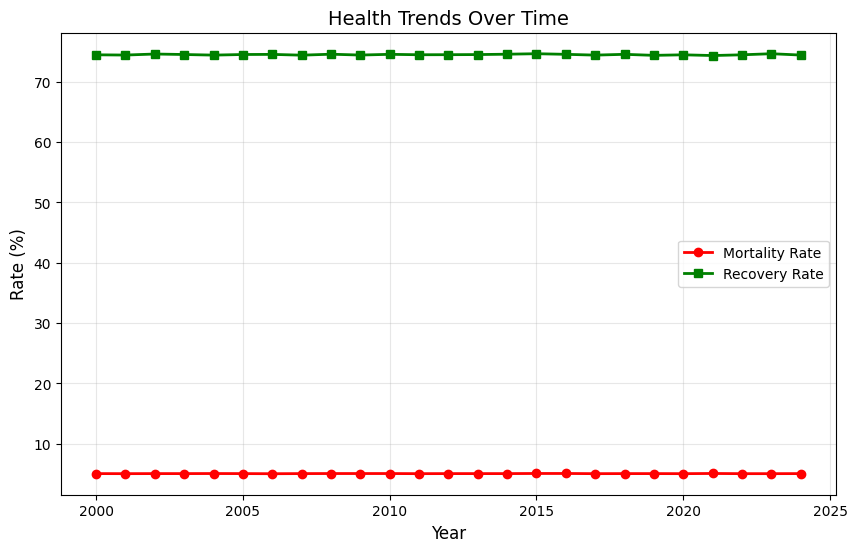

In [46]:
# Group by Year — compute trends over time
# To help identify health improvements, declines, or patternd across years
print("\n" + "="*60)
print("3. GROUP BY YEAR - TRENDS OVER TIME")
print("="*60)

# Group data by 'Year' and calculate average metrics for each year showing health evolutions over time
year_trend = df_cleaned.groupby('Year').agg({
    'Mortality Rate (%)': 'mean',
    'Recovery Rate (%)': 'mean',
    'Prevalence Rate (%)': 'mean',
    'Healthcare Access (%)': 'mean'
}).round(2)
# Display the numerical trends table
print(year_trend)

# Visualize trends to easily plot patterns, correlations, and anomalies
# import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a new figure with custom size
plt.figure(figsize=(10, 6)) 
# Plot 1 For mortality rate trend (Red Line)
plt.plot(year_trend.index, year_trend['Mortality Rate (%)'], 
         marker='o', linewidth=2, color='red', label='Mortality Rate')
# Plot for Recovery rate trend (Green Line)
plt.plot(year_trend.index, year_trend['Recovery Rate (%)'], 
         marker='s', linewidth=2, color='green', label='Recovery Rate')
plt.title('Health Trends Over Time', fontsize=14) # Main Title
plt.xlabel('Year', fontsize=12) # X-axis label
plt.ylabel('Rate (%)', fontsize=12) # Y-axis Lable
plt.legend() # Shows line is which
plt.grid(True, alpha=0.3) # Light grid for easier understanding
plt.show() # Display the plot

In [47]:
# Any joins/merges with additional data sources (if applicable)
# How to merge datasets if additional sources exist
print("\n" + "="*60)
print("4. JOINS/MERGES")
print("="*60)

# Check if you have any additional data files
# Import operating system module for file system operations
# This allows us to check what fies are available in the current directory
import os

print("Checking for additional data files...")
additional_files = [f for f in os.listdir() if f.endswith('.csv')]
print(f"CSV files in current directory: {additional_files}")

# If you have another dataset, this template is used to merge with the cleaned dataset:
#additional_data = pd.read_csv('your_second_file.csv')
#merged_data = df_cleaned.merge(additional_data, on='Country', how='left')

# If no additional data:
print("\nNo additional data sources found for join/merge.")
print("(This requirement is optional - skip if not applicable)")


4. JOINS/MERGES
Checking for additional data files...
CSV files in current directory: []

No additional data sources found for join/merge.
(This requirement is optional - skip if not applicable)


In [48]:
# Pivot table or cross-tabulation (e.g., Disease Category x Age Group)
# To anlyze relationships between two categorical variables
print("\n" + "="*60)
print("5. PIVOT TABLE: Disease Category x Age Group")
print("="*60)

# Pivot table - Reshapes the data to showaverage mortality rate by Disease Category and Age Group
pivot_mortality = pd.pivot_table(
    df_cleaned,
    values='Mortality Rate (%)', #The numeric column we want to aggregate
    index='Disease Category', # Variable that becomes row headers ( categories)
    columns='Age Group', # Variable that becomes column headers (age groups)
    aggfunc='mean', # Combine multiple values(mean=average)
    fill_value=0 # What to put on empty cells(0 means no data)
)

print("Average Mortality Rate (%) by Disease Category and Age Group:")
print(pivot_mortality)

# Cross-tabulation - count of records
# Check i we have enough data for each combination of disease category
print("\n" + "="*60)
print("CROSS-TABULATION: Disease Category x Age Group (counts)")
print("="*60)

# pd.crosstab creates a frequency table showing how many records exist for each combination of disease category and age group
crosstab = pd.crosstab(
    df_cleaned['Disease Category'], # Disease type
    df_cleaned['Age Group'] # Age group(brackets)
)

print("Number of records by Disease Category and Age Group:")
print(crosstab)


5. PIVOT TABLE: Disease Category x Age Group
Average Mortality Rate (%) by Disease Category and Age Group:
Age Group             0-18     19-35     36-60       61+
Disease Category                                        
autoimmune        5.054266  5.028000  5.004299  5.027806
bacterial         5.021933  5.053864  5.056270  5.049850
cardiovascular    5.055634  5.042020  5.076982  5.075848
chronic           5.036319  5.047136  5.054091  5.035482
genetic           5.043225  5.064652  5.043831  5.021656
infectious        5.032317  5.077007  5.066500  5.037451
metabolic         5.092013  5.059552  5.083858  5.072245
neurological      5.060588  5.040003  5.069523  5.059458
parasitic         5.042239  5.040563  5.033914  5.019966
respiratory       5.027493  5.058254  5.041978  5.069910
viral             5.082434  5.049989  5.048649  5.037450

CROSS-TABULATION: Disease Category x Age Group (counts)
Number of records by Disease Category and Age Group:
Age Group          0-18  19-35  36-60    

---
## 5. Feature Engineering

**What to do here:**
- Create **new derived columns** that add analytical value, for example:
  - `Mortality_to_Prevalence_Ratio` = Mortality Rate / Prevalence Rate
  - `Healthcare_Gap` = 100 - Healthcare Access (%)
  - `High_Mortality_Flag` = 1 if Mortality Rate > threshold, else 0
  - `Decade` = Year grouped into decades (2000s, 2010s, 2020s)
  - Encoded versions of categorical columns (label encoding or one-hot)
- Document **why** each feature was created and what it represents

**Deliverable check:** Explicitly addresses the "Feature engineering" requirement.

In [49]:
# Create ratio/derived numerical features code

#Severity Index was selected to check if the disease is becoming more severe/ deadly over time. 
df = df_cleaned.copy()

df['Severity_Index'] = df['Mortality Rate (%)'] / (df['Prevalence Rate (%)'] + 1e-5)
# 1E-5 added to prevent division by zero in cases where Prevalence Rate is 0
#Prevalence rate is used as a proxy for how widespread the disease is
# Mortality Rate indicates how deadly it is. 

# DALY_Intensity was selected to check if medical interventions are actually working.

# # DALYs adjusted by Population Affected
df['DALY_Intensity'] = df['DALYs'] / df['Population Affected']

# DALYs (Disability-Adjusted Life Years) is a measure of overall disease burden, expressed as the number of years lost due to ill-health, disability, or early death.
# By dividing DALYs by Population Affected, we get a per-person burden of the disease
# This can help us understand if the disease is becoming more or less burdensome on individuals, even if the total number of cases is changing.
display(df[['Severity_Index', 'DALY_Intensity']].head())

,Severity_Index,DALY_Intensity
0,8.863065,0.009539
1,0.702247,0.003730
2,6.835090,0.000265
3,0.852562,0.007174
4,8.445681,0.005988


In [50]:
# Binary flag features

# Vaccine_Available_Flag: 1 if vaccine/treatment is available, 0 otherwise
df['Vaccine_Available_Flag'] = (df['Availability of Vaccines/Treatment'].str.lower() == 'yes').astype(int)

# High_Risk_Demographic: True if age group is 61+ (most vulnerable)
df['High_Risk_Demographic'] = df['Age Group'].str.lower() == '61+'

# Avg_Incidence_Disease: mean incidence rate per disease name (group-level feature)
df['Avg_Incidence_Disease'] = df.groupby('Disease Name')['Incidence Rate (%)'].transform('mean')

# Mortality_YoY_Change: year-on-year change in mortality rate per country+disease
df = df.sort_values(['Country', 'Disease Name', 'Year'])
df['Mortality_YoY_Change'] = df.groupby(['Country', 'Disease Name'])['Mortality Rate (%)'].diff().round(2)

# Weighted_Time_Impact: improvement scaled by years since 2000
df['Weighted_Time_Impact'] = df['Improvement in 5 Years (%)'] * (df['Year'] - 2000) / 24

print('Binary and derived features created.')
print(df[['Vaccine_Available_Flag', 'High_Risk_Demographic', 'Avg_Incidence_Disease', 'Mortality_YoY_Change', 'Weighted_Time_Impact']].head(3))

Binary and derived features created.
       Vaccine_Available_Flag  High_Risk_Demographic  Avg_Incidence_Disease  \
10783                       0                  False                7.53279   
31371                       1                  False                7.53279   
33365                       1                   True                7.53279   

       Mortality_YoY_Change  Weighted_Time_Impact  
10783                   NaN                   0.0  
31371                 -4.21                   0.0  
33365                  2.69                   0.0  


In [51]:
# Time-based features

# decade: floor year to nearest decade (2000, 2010, 2020)
df['decade'] = (df['Year'] // 10) * 10

print('Time-based features created.')
print(df[['Year', 'decade']].drop_duplicates().sort_values('Year').head(10))

Time-based features created.
       Year  decade
10783  2000    2000
13108  2001    2000
11634  2002    2000
341    2003    2000
3531   2004    2000
30106  2005    2000
22564  2006    2000
13795  2007    2000
1061   2008    2000
14175  2009    2000


In [52]:
# Label encoding for categorical columns used in modeling
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Demographic_encoded: encodes Age Group (0-18, 19-35, 36-60, 61+)
df['Demographic_encoded'] = le.fit_transform(df['Age Group'].str.lower())

# Gender_Encoded: encodes Gender (female=0, male=1, other=2)
df['Gender_Encoded'] = le.fit_transform(df['Gender'].str.lower())

# Disease_Category_Encoded: encodes Disease Category
df['Disease_Category_Encoded'] = le.fit_transform(df['Disease Category'].str.lower())

print('Encoding complete.')
print(df[['Age Group', 'Demographic_encoded', 'Gender', 'Gender_Encoded', 'Disease Category', 'Disease_Category_Encoded']].drop_duplicates().sort_values('Demographic_encoded').head(10))

Encoding complete.
       Age Group  Demographic_encoded  Gender  Gender_Encoded  \
10783       0-18                    0  female               0   
40089       0-18                    0   other               2   
84233       0-18                    0    male               1   
86106       0-18                    0   other               2   
253372      0-18                    0    male               1   
436601      0-18                    0  female               0   
209438      0-18                    0   other               2   
457069      0-18                    0    male               1   
725996      0-18                    0    male               1   
733774      0-18                    0  female               0   

       Disease Category  Disease_Category_Encoded  
10783       respiratory                         9  
40089        autoimmune                         0  
84233        autoimmune                         0  
86106         bacterial                         1  
25337

In [53]:
# Section 5 — Preview all engineered features

new_features = [
    'Severity_Index', 'DALY_Intensity', 'Avg_Incidence_Disease',
    'High_Risk_Demographic', 'Vaccine_Available_Flag', 'Mortality_YoY_Change',
    'Weighted_Time_Impact', 'Demographic_encoded', 'decade',
    'Gender_Encoded', 'Disease_Category_Encoded'
]

print(f'Total columns in dataset: {len(df.columns)}')
print(f'Engineered features: {len(new_features)}')
display(df[new_features].head())

Total columns in dataset: 33
Engineered features: 11


,Severity_Index,DALY_Intensity,Avg_Incidence_Disease,High_Risk_Demographic,Vaccine_Available_Flag,Mortality_YoY_Change,Weighted_Time_Impact,Demographic_encoded,decade,Gender_Encoded,Disease_Category_Encoded
10783,1.379601,0.007657,7.53279,False,0,NaN,0.0,0,2000,0,9
31371,0.278309,0.002306,7.53279,False,1,-4.21,0.0,1,2000,0,3
33365,2.668823,0.027626,7.53279,True,1,2.69,0.0,3,2000,1,6
40089,0.359509,0.017694,7.53279,False,0,-2.36,0.0,0,2000,2,0
52163,0.259574,0.023886,7.53279,False,1,-4.03,0.0,2,2000,2,3


---
## 6. Final Pipeline & Dataset Export

**What to do here:**
- Print a final summary of the cleaned + engineered dataset (shape, columns, dtypes)
- Export the processed dataset to `data/processed/` as a CSV file
- Write a **Data Dictionary** table below documenting every transformation made

**Deliverable check:** Delivers the "Clean and structured dataset" and "Documentation of transformations".

In [54]:
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'global_health_enriched.csv.gz'
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')
for col in df.select_dtypes(include=['int64']).columns:
    if df[col].min() > -2147483648 and df[col].max() < 2147483647:
        df[col] = df[col].astype('int32')

df.to_csv(PROCESSED_PATH, index=False, compression='gzip')

file_size_mb = PROCESSED_PATH.stat().st_size / 1024**2

print("=" * 150)
print(f'Final Dataset Shape: {df.shape}')
print("=" * 150)

Final Dataset Shape: (1000000, 33)


### Data Dictionary — Transformations Applied

| Column / Feature                  | Type      | Description                                           | Transformation Applied |
|---------------------------|-----------|-------------------------------------------------------|------------------------|
| Country                       | category  | Country name                                          | Lowercased, cast to category |
| Year                          | int32     | Year of record                                        | Cast to int32 |
| Disease Name                  | category  | Name of disease                                       | Lowercased, cast to category |
| Disease Category              | category  | Disease classification                                | Lowercased, cast to category |
| Prevalence Rate (%)           | float32   | % of population with disease                          | Cast to float32 |
| Incidence Rate (%)            | float32   | % of new cases per year                               | Cast to float32 |
| Mortality Rate (%)            | float32   | % of deaths from disease                              | Cast to float32 |
| Age Group                     | category  | Age bracket of affected group                         | Lowercased, cast to category |
| Gender                        | category  | Gender of affected group                              | Lowercased, cast to category |
| Population Affected           | int32     | Number of people affected                             | Cast to int32 |
| Healthcare Access (%)         | float32   | % with access to healthcare                           | Cast to float32 |
| Doctors per 1000              | float32   | Doctors per 1000 population                           | Cast to float32 |
| Hospital Beds per 1000        | float32   | Hospital beds per 1000 population                     | Cast to float32 |
| Treatment Type                | category  | Type of treatment used                                | Lowercased, cast to category |
| Average Treatment Cost (USD)  | int32     | Average cost of treatment in USD                      | Cast to int32 |
| Availability of Vaccines/Treatment | category | Yes/No vaccine availability                        | Lowercased, cast to category |
| Recovery Rate (%)             | float32   | % of patients who recovered                           | Cast to float32 |
| DALYs                         | int32     | Disability-Adjusted Life Years lost                   | Cast to int32 |
| Improvement in 5 Years (%)    | float32   | % health improvement over 5 years                     | Cast to float32 |
| Per Capita Income (USD)       | int32     | Average income per person in USD                      | Cast to int32 |
| Education Index               | float32   | Education level index (0–1)                           | Cast to float32 |
| Urbanization Rate (%)         | float32   | % of urban population                                 | Cast to float32 |
| Severity_Index                | float32   | How deadly a disease is relative to its spread       | Derived: Mortality Rate / (Prevalence Rate + 1e-5) |
| DALY_Intensity                | float32   | Per-person disease burden                             | Derived: DALYs / Population Affected |
| Vaccine_Available_Flag        | int32     | 1 if vaccine/treatment available, 0 otherwise        | Derived from Availability of Vaccines/Treatment |
| High_Risk_Demographic         | bool      | True if Age Group is 61+                              | Derived from Age Group |
| Avg_Incidence_Disease         | float32   | Mean incidence rate per disease name                  | Group transform on Disease Name |
| Mortality_YoY_Change          | float32   | Year-on-year change in mortality per country+disease | diff() on Country + Disease Name + Year |
| Weighted_Time_Impact          | float32   | Improvement scaled by years since 2000                | Derived: Improvement × (Year − 2000) / 24 |
| decade                        | int32     | Decade of the record                                  | Derived: (Year // 10) × 10 |
| Demographic_encoded           | int32     | Label-encoded Age Group                               | LabelEncoder on Age Group |
| Gender_Encoded                | int32     | Label-encoded Gender                                  | LabelEncoder on Gender |
| Disease_Category_Encoded      | int32     | Label-encoded Disease Category                        | LabelEncoder on Disease Category |

### Pipeline Summary

| Step                     | Action                                           | Rows Before | Rows After | Columns Before | Columns After |
|--------------------------|--------------------------------------------------|-------------|------------|----------------|---------------|
| Raw load                 | Read CSV from data/raw/                          | —           | 1,000,000  | —              | 22            |
| Remove duplicates        | drop_duplicates()                                | 1,000,000   | 1,000,000  | 22             | 22            |
| Handle missing values    | No missing values found                          | 1,000,000   | 1,000,000  | 22             | 22            |
| Handle outliers          | No outliers detected (IQR + Z-score)             | 1,000,000   | 1,000,000  | 22             | 22            |
| Type conversion          | Cast to category / float32 / int32               | 1,000,000   | 1,000,000  | 22             | 22            |
| String standardisation   | Lowercase + strip all object columns             | 1,000,000   | 1,000,000  | 22             | 22            |
| Feature engineering      | 11 new features created                          | 1,000,000   | 1,000,000  | 22             | 33            |
| Final export             | Saved as global_health_enriched.csv.gz           | 1,000,000   | 1,000,000  | 33             | 33            |
